In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("Heart.csv")

In [4]:
df

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [5]:
df = df.dropna()
df = df.drop("Unnamed: 0", axis=1)
df = pd.get_dummies(df, columns=["ChestPain","Thal"], drop_first=True)
df["AHD"] = df["AHD"].map({"No":0, "Yes":1})

In [23]:
df

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
0,63,1,145,233,1,2,150,0,2.3,3,0.0,0,False,False,True,False,False
1,67,1,160,286,0,2,108,1,1.5,2,3.0,1,False,False,False,True,False
2,67,1,120,229,0,2,129,1,2.6,2,2.0,1,False,False,False,False,True
3,37,1,130,250,0,0,187,0,3.5,3,0.0,0,True,False,False,True,False
4,41,0,130,204,0,2,172,0,1.4,1,0.0,0,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,140,241,0,0,123,1,0.2,2,0.0,1,False,False,False,False,True
298,45,1,110,264,0,0,132,0,1.2,2,0.0,1,False,False,True,False,True
299,68,1,144,193,1,0,141,0,3.4,2,2.0,1,False,False,False,False,True
300,57,1,130,131,0,0,115,1,1.2,2,1.0,1,False,False,False,False,True


In [30]:
x = df.drop("AHD",axis =1)
y = df["AHD"]

num_cols = ["Age","RestBP","Chol","MaxHR","Oldpeak","Ca"]

In [31]:
x

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
0,0.936181,1,0.750380,-0.276443,1,2,0.017494,0,1.068965,3,-0.721976,False,False,True,False,False
1,1.378929,1,1.596266,0.744555,0,2,-1.816334,1,0.381773,2,2.478425,False,False,False,True,False
2,1.378929,1,-0.659431,-0.353500,0,2,-0.899420,1,1.326662,2,1.411625,False,False,False,False,True
3,-1.941680,1,-0.095506,0.051047,0,0,1.633010,0,2.099753,3,-0.721976,True,False,False,True,False
4,-1.498933,0,-0.095506,-0.835103,0,2,0.978071,0,0.295874,1,-0.721976,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,0.272059,0,0.468418,-0.122330,0,0,-1.161395,1,-0.734914,2,-0.721976,False,False,False,False,True
298,-1.056185,1,-1.223355,0.320744,0,0,-0.768432,0,0.124076,2,-0.721976,False,False,True,False,True
299,1.489615,1,0.693988,-1.047008,1,0,-0.375469,0,2.013854,2,1.411625,False,False,False,False,True
300,0.272059,1,-0.095506,-2.241384,0,0,-1.510696,1,0.124076,2,0.344824,False,False,False,False,True


In [33]:
df.groupby("Sex")["AHD"].agg(["count","sum","mean"])

,count,sum,mean
Sex,,,
0,96,25,0.260417
1,201,112,0.557214


Meaning: 
Sex = 1 → Male
Sex = 0 → Female

In [6]:
df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,0.461279
std,9.049736,0.468500,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.499340
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [55]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_values = range(1, 31)
mean_scores = []

for k in k_values:
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(pipe, x, y, cv=kf, scoring="accuracy")
    mean_scores.append(scores.mean())

best_k = k_values[np.argmax(mean_scores)]
print("Best k:", best_k)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

y_pred = cross_val_predict(pipe, x, y, cv=kf)
y_prob = cross_val_predict(pipe, x, y, cv=kf, method="predict_proba")[:,1]

Best k: 14


In [56]:
print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
cm = confusion_matrix(y, y_pred)
print(cm)
fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

Fold accuracies: [0.9        0.81666667 0.79661017 0.83050847 0.81355932]
Mean accuracy: 0.8314689265536724
[[142  18]
 [ 28 109]]


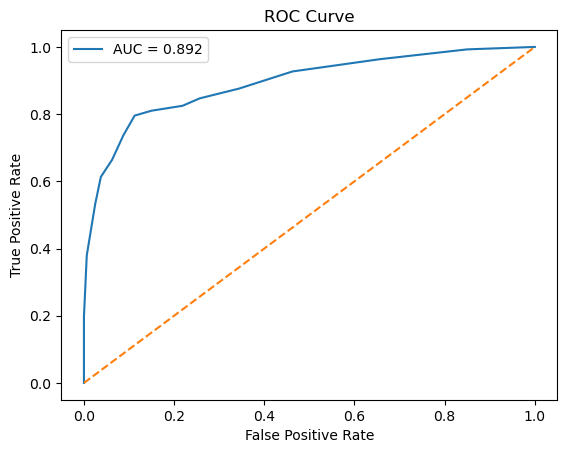

In [57]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {"solver": "svd", "shrinkage": None},
    {"solver": "lsqr", "shrinkage": None},
    {"solver": "lsqr", "shrinkage": "auto"},
    {"solver": "lsqr", "shrinkage": 0.1},
    {"solver": "lsqr", "shrinkage": 0.5},
    {"solver": "eigen", "shrinkage": None},
    {"solver": "eigen", "shrinkage": "auto"},
    {"solver": "eigen", "shrinkage": 0.1},
    {"solver": "eigen", "shrinkage": 0.5},
]

mean_scores = []

for params in param_grid:
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(
            solver=params["solver"],
            shrinkage=params["shrinkage"]
        ))
    ])
    
    scores = cross_val_score(pipe, x, y, cv=kf, scoring="accuracy")
    mean_scores.append(scores.mean())

best_index = np.argmax(mean_scores)
best_params = param_grid[best_index]

print("Best parameters:", best_params)
print("Best CV accuracy:", mean_scores[best_index])

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(
        solver=best_params["solver"],
        shrinkage=best_params["shrinkage"]
    ))
])

y_pred = cross_val_predict(pipe, x, y, cv=kf)
y_prob = cross_val_predict(pipe, x, y, cv=kf, method="predict_proba")[:, 1]

Best parameters: {'solver': 'lsqr', 'shrinkage': 'auto'}
Best CV accuracy: 0.8382485875706216


Accuracy: 0.8383838383838383
Confusion Matrix:
[[142  18]
 [ 30 107]]


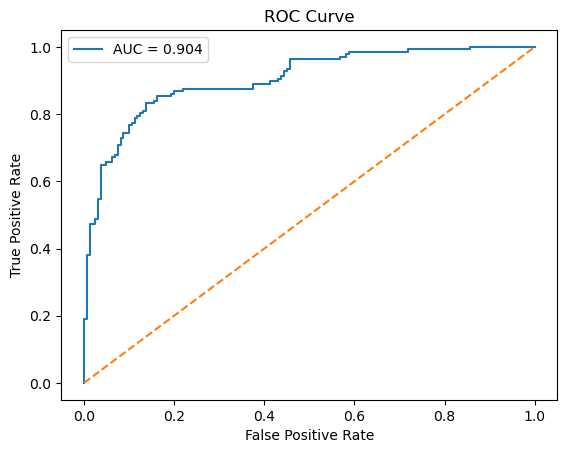

In [60]:
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)
fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

Best C: 0.1
Best CV accuracy: 0.8349152542372881
Accuracy: 0.835016835016835
Confusion Matrix:
[[142  18]
 [ 31 106]]


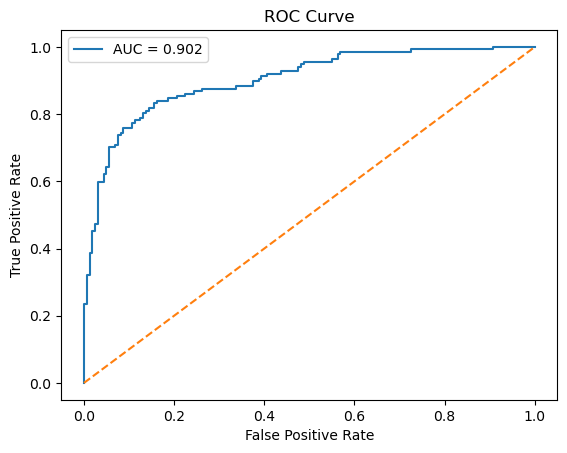

In [62]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
mean_scores = []

for C in C_values:
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(C=C, max_iter=1000))
    ])
    
    scores = cross_val_score(pipe, x, y, cv=kf, scoring="accuracy")
    mean_scores.append(scores.mean())

best_C = C_values[np.argmax(mean_scores)]
print("Best C:", best_C)
print("Best CV accuracy:", max(mean_scores))

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(C=best_C, max_iter=1000))
])

y_pred = cross_val_predict(pipe, x, y, cv=kf)
y_prob = cross_val_predict(pipe, x, y, cv=kf, method="predict_proba")[:, 1]

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()